# PhysNet, block by block: reproducing the original implementation with `xnns`

[PhysNet (Unke & Meuwly, *JCTC* **15**, 3678, 2019)](https://doi.org/10.1021/acs.jctc.9b00181)
is a message-passing HDNN that predicts **energies, forces, partial charges and
dipoles**, with the physics (switched/shielded electrostatics of the predicted
charges and Grimme D3(BJ) dispersion) built into the energy expression. The
original implementation ([MMunibas/PhysNet](https://github.com/MMunibas/PhysNet))
is TensorFlow 1.x; `xnns.dnn.models.physnet` is a pure-PyTorch translation on
the xnns abstractions. This notebook walks through every block and checks each
against the **original TF graph** on the same inputs, ending with a whole-model
weight transplant and an energy/force/charge parity check at machine precision,
the same protocol as the MACE / NequIP / Allegro / CACE companions.

> The original only ever ran in float32. Three tiny **harness** patches (noted
> inline, none changing the math) let its graph run in float64 here so the
> comparison is at machine precision: dropout with `keep_prob=1` is replaced by
> the identity, the RBF layer receives the model dtype (upstream forgets to
> forward it), and the activation's `log(2)` constant is computed in float64.

## 0. Setup: TF1 compatibility mode + `float64`

In [1]:
# silence the expected warnings / TF chatter
import logging, os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import subprocess, sys, tempfile
import numpy as np

# ---- the original TF1 PhysNet (cloned on demand) ----
UPSTREAM = os.environ.get("PHYSNET_UPSTREAM_PATH",
                          os.path.join(tempfile.gettempdir(), "physnet-upstream"))
if not os.path.isdir(UPSTREAM):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/MMunibas/PhysNet", UPSTREAM], check=True)

import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
tf.get_logger().setLevel("ERROR")
sys.modules["tensorflow"] = tf          # upstream modules do `import tensorflow as tf`
# upstream applies dropout with keep_prob = 1.0 (identity); its float32
# placeholder trips TF2's dtype check in float64 graphs
tf.nn.dropout = lambda x, keep_prob=None, **kw: x

sys.path.insert(0, UPSTREAM)
import neural_network.NeuralNetwork as _nnmod
from neural_network.NeuralNetwork import NeuralNetwork

# upstream forgets to forward dtype to RBFLayer (float32 hard-coded)
_OrigRBF = _nnmod.RBFLayer
_nnmod.RBFLayer = lambda K, cutoff, scope=None: _OrigRBF(K, cutoff, scope=scope, dtype=tf.float64)

import torch
torch.set_default_dtype(torch.float64)
import xnns
print("xnns:", xnns.__version__, "| tensorflow:", tf.__version__, "| torch:", torch.__version__)

xnns: 0.1.0 | tensorflow: 2.21.0 | torch: 2.12.1+cpu


### A toy system

A charged 8-atom H/C/O cluster with the **full ordered pair list**, upstream's
default molecular mode (no long-range cutoff), so every term including the
un-damped electrostatics is exercised.

In [2]:
F_DIM, K, SR_CUT, NB, NRA, NRI, NRO = 24, 16, 4.0, 3, 2, 3, 1
Q_TOT = 1.0

rng = np.random.default_rng(7)
N = 8
R_np = rng.uniform(0, 3.5, (N, 3))
Z_np = np.array([8, 1, 1, 6, 1, 1, 1, 1])
idx_i = np.repeat(np.arange(N), N - 1)                                # centers
idx_j = np.concatenate([[j for j in range(N) if j != i] for i in range(N)])  # neighbors
print(f"{N} atoms, {len(idx_i)} ordered pairs, total charge {Q_TOT}")

8 atoms, 56 ordered pairs, total charge 1.0


## The PhysNet architecture in one picture

1. **Embedding** *(eq 3)*: nuclear charges index a 95-row learnable table of
   $F$-vectors: every element up to Pu, no species list.
2. **Radial basis** *(eqs 7–8)*: $g_k(r) = \phi(r)\,e^{-\beta_k(e^{-r}-\mu_k)^2}$,
   learnable centers/widths (softplus-positive), smooth cutoff $\phi$. The
   $e^{-r}$ argument biases the learnable attention masks toward exponential
   decay; bound-state wave functions decay exponentially.
3. **Modules** ($N_{\rm module}$ stacked): an interaction block computes the
   message $v$ from gated features and the attention mask $G\,g(r_{ij})$
   *(eqs 5–6)* and refines atom-wise through pre-activation residual blocks
   *(eq 4)*; an output block per module predicts $(E_i^m, q_i^m)$ through a
   zero-initialized head *(eq 9)*.
4. **Scale/shift** *(eq 10)*: module outputs are summed and scaled/shifted per
   element.
5. **Charges → physics** *(eqs 12–14)*: charges are corrected to the exact
   total charge, then enter a shielded ($1/\sqrt{r^2+1}$), smoothstep-switched
   Coulomb term; D3(BJ) dispersion (with learnable $s_6, s_8, a_1, a_2$)
   completes the energy. Dipoles come from eq 15.

In [3]:
# --- build both models once; every block below compares their internals ---
act = lambda x: tf.nn.softplus(x) - np.log(2.0)   # float64-exact shifted softplus
nn = NeuralNetwork(F=F_DIM, K=K, sr_cut=SR_CUT, lr_cut=None, num_blocks=NB,
                   num_residual_atomic=NRA, num_residual_interaction=NRI,
                   num_residual_output=NRO, use_electrostatic=True,
                   use_dispersion=True, Eshift=0.1, Escale=1.3,
                   Qshift=0.01, Qscale=0.9, activation_fn=act,
                   dtype=tf.float64, scope="nn", seed=7)

Z_t = tf.constant(Z_np, tf.int32); R_t = tf.constant(R_np, tf.float64)
ii_t = tf.constant(idx_i, tf.int32); jj_t = tf.constant(idx_j, tf.int32)
Qt_t = tf.constant([Q_TOT], tf.float64)

Dij_op = nn.calculate_interatomic_distances(R_t, ii_t, jj_t)
rbf_op = nn.rbf_layer(Dij_op)
x0_op = tf.gather(nn.embeddings, Z_t)
xs_ops, outs_ops = [x0_op], []
for i in range(NB):
    xs_ops.append(nn.interaction_block[i](xs_ops[-1], rbf_op, ii_t, jj_t))
    outs_ops.append(nn.output_block[i](xs_ops[-1]))
Ea_op, Qa_raw_op, _, nh_op = nn.atomic_properties(Z_t, R_t, ii_t, jj_t)
Qa_op = nn.scaled_charges(Z_t, Qa_raw_op, Q_tot=Qt_t)
Eele_op = nn.electrostatic_energy_per_atom(Dij_op, Qa_op, ii_t, jj_t)
from neural_network.grimme_d3.grimme_d3 import edisp as tf_edisp, d3_autoang, d3_autoev
Edisp_op = d3_autoev * tf_edisp(Z_t, Dij_op / d3_autoang, ii_t, jj_t,
                                s6=nn.s6, s8=nn.s8, a1=nn.a1, a2=nn.a2)
E_op, F_op = nn.energy_and_forces(Z_t, R_t, ii_t, jj_t, Q_tot=Qt_t)

sess = tf.Session()
sess.run(tf.global_variables_initializer())
# the k2f and output heads are zero-initialized upstream (they would leave the
# network body unexercised) -- randomize them for a meaningful comparison
rng_w = np.random.default_rng(107)
for v in tf.global_variables():
    if "k2f/W" in v.name or "dense_layer/W" in v.name:
        sess.run(v.assign(0.2 * rng_w.standard_normal(v.shape.as_list())))
vals = {v.name: sess.run(v) for v in tf.global_variables()}

# ---- the xnns PhysNet, weights transplanted ----
from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput

cfg = from_dict({"model": {"name": "physnet", "cutoff": SR_CUT,
                           "n_features": F_DIM, "n_rbf": K, "n_interactions": NB,
                           "extra": {"num_residual_atomic": NRA,
                                     "num_residual_interaction": NRI,
                                     "num_residual_output": NRO}}})
x = build_model(cfg.model)

def transplant_tf_to_torch(x, vals, num_blocks, scope="nn"):
    """Copy every variable of the original TF PhysNet into the xnns PhysNet."""
    import torch
    def g(name): return torch.tensor(np.asarray(vals[f"{scope}/{name}:0"]))
    with torch.no_grad():
        x.embeddings.copy_(g("embeddings"))
        x.rbf_layer.centers.copy_(g("rbf_layer/centers"))
        x.rbf_layer.widths.copy_(g("rbf_layer/widths"))
        x.Eshift.copy_(g("Eshift")); x.Escale.copy_(g("Escale"))
        x.Qshift.copy_(g("Qshift")); x.Qscale.copy_(g("Qscale"))
        x._s6.copy_(g("s6")); x._s8.copy_(g("s8"))
        x._a1.copy_(g("a1")); x._a2.copy_(g("a2"))
        def cd(dst, sc, bias=True):
            dst.weight.copy_(g(f"{sc}/W"))
            if bias: dst.bias.copy_(g(f"{sc}/b"))
        def cr(dst, sc):
            cd(dst.dense, f"{sc}/dense"); cd(dst.residual, f"{sc}/residual")
        for b in range(num_blocks):
            ib, sc = x.interaction_blocks[b], f"interaction_block{b}"
            il = ib.interaction
            cd(il.k2f, f"{sc}/interaction_layer/k2f", bias=False)
            cd(il.dense_i, f"{sc}/interaction_layer/dense_i")
            cd(il.dense_j, f"{sc}/interaction_layer/dense_j")
            for k, r in enumerate(il.residuals):
                cr(r, f"{sc}/interaction_layer/residual_layer{k}")
            cd(il.dense, f"{sc}/interaction_layer/dense")
            il.u.copy_(g(f"{sc}/interaction_layer/u"))
            for k, r in enumerate(ib.residuals):
                cr(r, f"{sc}/residual_layer{k}")
            ob = x.output_blocks[b]
            for k, r in enumerate(ob.residuals):
                cr(r, f"output_block{b}/residual_layer{k}")
            ob.dense.weight.copy_(g(f"output_block{b}/dense_layer/W"))

transplant_tf_to_torch(x, vals, NB)
p_tf = sum(int(np.prod(v.shape)) for k, v in vals.items())
p_x = sum(p.numel() for p in x.parameters())
print(f"parameters: original {p_tf} | xnns {p_x} (identical tables and layers)")

parameters: original 31064 | xnns 31064 (identical tables and layers)


## Block 1: Element embedding  ·  eq 3

$\mathbf{x}_i^0 = \mathbf{e}_{Z_i}$: a learnable 95-row table indexed directly
by nuclear charge (uniform $[-\sqrt3, \sqrt3]$ init). No one-hot, no species
list; PhysNet is alchemical by construction.

In [4]:
x0_tf = sess.run(x0_op)
x0_x = x.embeddings[torch.tensor(Z_np)]
print("embedding shape:", tuple(x0_x.shape))
print("max |xnns - original| =", np.abs(x0_x.detach().numpy() - x0_tf).max())

embedding shape: (8, 24)
max |xnns - original| = 0.0


## Block 2: Radial basis functions  ·  eqs 7–8

$g_k(r_{ij}) = \phi(r_{ij})\exp\!\big(-\beta_k(\exp(-r_{ij})-\mu_k)^2\big)$ with
$\phi(r) = 1 - 6x^5 + 15x^4 - 10x^3$. Centers equally spaced on
$[\exp(-r_{\rm cut}), 1]$ and a shared width, both stored pre-softplus so they
stay positive while training (compare paper fig 2).

max |Dij diff| = 4.440892098500626e-16
max |rbf diff| = 8.673617379884035e-16


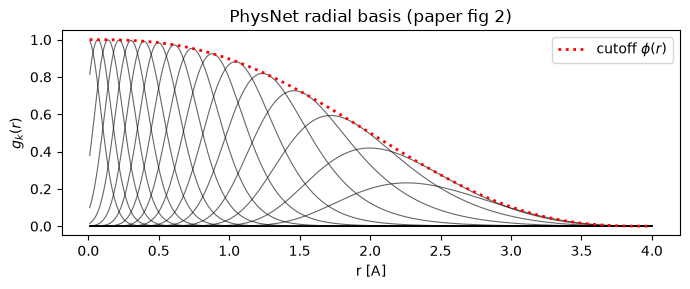

In [5]:
import matplotlib.pyplot as plt
Dij_tf, rbf_tf = sess.run([Dij_op, rbf_op])
ei = torch.tensor(np.stack([idx_j, idx_i]))
pos = torch.tensor(R_np)
D_x = (pos[ei[1]] - pos[ei[0]]).norm(dim=-1)
rbf_x = x.rbf_layer(D_x)
print("max |Dij diff| =", np.abs(D_x.numpy() - Dij_tf).max())
print("max |rbf diff| =", np.abs(rbf_x.detach().numpy() - rbf_tf).max())

r = torch.linspace(0.01, SR_CUT, 400)
with torch.no_grad():
    G = x.rbf_layer(r)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(r, G.numpy(), lw=0.8, color="k", alpha=0.6)
ax.plot(r, x.rbf_layer.cutoff_fn(r).numpy(), "r:", lw=2, label=r"cutoff $\phi(r)$")
ax.set_xlabel("r [A]"); ax.set_ylabel(r"$g_k(r)$"); ax.legend()
ax.set_title("PhysNet radial basis (paper fig 2)"); plt.tight_layout(); plt.show()

## Block 3: Interaction blocks (messages + residual refinements)  ·  eqs 4–6

$\tilde v_i = \sigma(W_I \sigma(x_i) + b_I) + \sum_j G g(r_{ij}) \circ
\sigma(W_J \sigma(x_j) + b_J)$, refined through pre-activation residual blocks,
then $x' = u \circ x + W\sigma(v) + b$ with the learnable gate $u$. The
attention mask ``k2f`` selects features by distance; the shifted-softplus is
evaluated in its exact form ``max(x,0) + log1p(exp(-|x|))`` (PyTorch's
``F.softplus`` goes linear above threshold 20 and would cost ~1e-9).

In [6]:
xs_tf = sess.run(xs_ops)
xt = x0_x
for b in range(NB):
    xt = x.interaction_blocks[b](xt, rbf_x, ei[1], ei[0])
    print(f"block {b}: max |feature diff| = "
          f"{np.abs(xt.detach().numpy() - xs_tf[b + 1]).max():.3e}")

block 0: max |feature diff| = 8.882e-16
block 1: max |feature diff| = 1.110e-15
block 2: max |feature diff| = 1.554e-15


## Block 4: Output blocks, scale/shift, charge correction  ·  eqs 9–10, 14

Each module's zero-initialized head yields $(E_i^m, q_i^m)$; sums are scaled
and shifted **per element** ($E_{\rm shift}$ doubles as the per-species
reference energy; xnns' ``atomic_energies`` loads straight into it). Raw
charges are then corrected by $\tfrac{1}{N}(Q - \sum_i q_i)$ so they sum to the
exact total charge.

In [7]:
outs_tf, Ea_tf, Qa_tf, nh_tf = sess.run([outs_ops, Ea_op, Qa_op, nh_op])
xt = x0_x
for b in range(NB):
    xt = x.interaction_blocks[b](xt, rbf_x, ei[1], ei[0])
    o = x.output_blocks[b](xt)
    print(f"module {b}: max |output diff| = "
          f"{np.abs(o.detach().numpy() - outs_tf[b]).max():.3e}")

Ea_x, Qa_raw_x, Dij_x, nh_x, feats_x = x.atomic_properties(
    torch.tensor(Z_np), ei, pos[ei[1]] - pos[ei[0]])
Qa_x = x.scaled_charges(Qa_raw_x, torch.zeros(N, dtype=torch.long), 1,
                        torch.tensor([Q_TOT]))
print("max |scaled Ea diff| =", np.abs(Ea_x.detach().numpy() - Ea_tf).max())
print("max |corrected q diff| =", np.abs(Qa_x.detach().numpy() - Qa_tf).max())
print("sum q =", float(Qa_x.sum()), f"(= Q_tot = {Q_TOT})")
print("max |nh penalty diff| =", abs(float(nh_x) - float(nh_tf)))

module 0: max |output diff| = 3.608e-16
module 1: max |output diff| = 5.551e-16
module 2: max |output diff| = 5.829e-16
max |scaled Ea diff| = 8.881784197001252e-16
max |corrected q diff| = 4.718447854656915e-16
sum q = 1.0000000000000002 (= Q_tot = 1.0)
max |nh penalty diff| = 4.440892098500626e-16


## Block 5: Switched, shielded electrostatics  ·  eqs 12–13

$E_{\rm ele} = k_e/2\; q_i q_j \big[(1{-}s(r))/\sqrt{r^2+1} + s(r)/r\big]$ with
the smoothstep $s$ switching at $r_{\rm cut}/2$: shielded at short range to
avoid the singularity, exact Coulomb beyond. With a long-range cutoff the
expression is force-shifted to vanish smoothly.

electrostatic energy per atom [eV]: [-2.53761e+00  4.89060e-01  3.27140e-01  1.18878e+00  9.57310e-01
  4.10000e-04  2.45010e-01  5.74250e-01]
max |Eele diff| = 1.6653345369377348e-15


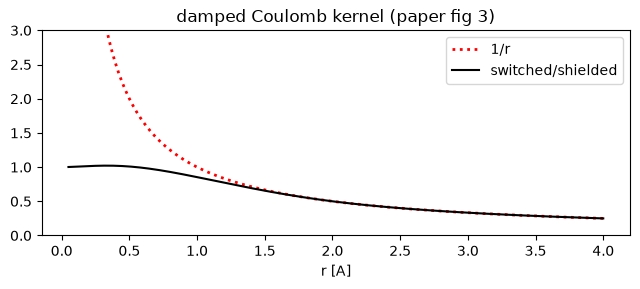

In [8]:
Eele_tf = sess.run(Eele_op)
Eele_x = x.electrostatic_energy_per_atom(D_x, Qa_x, ei[1], ei[0])
print("electrostatic energy per atom [eV]:", Eele_x.detach().numpy().round(5))
print("max |Eele diff| =", np.abs(Eele_x.detach().numpy() - Eele_tf).max())

rr = torch.linspace(0.05, SR_CUT, 300)
sw = x._switch(rr)
chi = (1 - sw) / torch.sqrt(rr**2 + 1) + sw / rr
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(rr, (1 / rr).numpy(), "r:", lw=2, label="1/r")
ax.plot(rr, chi.numpy(), "k-", label="switched/shielded")
ax.set_ylim(0, 3); ax.set_xlabel("r [A]"); ax.legend()
ax.set_title("damped Coulomb kernel (paper fig 3)"); plt.tight_layout(); plt.show()

## Block 6: Grimme D3(BJ) dispersion

`xnns.dnn.models.d3` is a statement-for-statement port of the TF `grimme_d3`
module (coordination numbers, Gaussian-weighted C6 interpolation from the
reference tables, BJ damping); the tables ship with xnns. $s_6, s_8, a_1, a_2$
are learnable through a softplus, initialized to the HF values.

In [9]:
Edisp_tf = sess.run(Edisp_op)
Edisp_x = x.dispersion_energy_per_atom(torch.tensor(Z_np), D_x, ei[1], ei[0])
print("dispersion energy per atom [eV]:", Edisp_x.detach().numpy().round(6))
print("max |Edisp diff| =", np.abs(Edisp_x.detach().numpy() - Edisp_tf).max())
print("s6, s8, a1, a2 =", [round(float(v), 4) for v in (x.s6, x.s8, x.a1, x.a2)])

dispersion energy per atom [eV]: [-0.122002 -0.102835 -0.094091 -0.200128 -0.12701  -0.071694 -0.096155
 -0.109732]
max |Edisp diff| = 2.7755575615628914e-17
s6, s8, a1, a2 = [1.0, 0.9171, 0.3385, 2.883]


## Capstone: transplant a *whole* PhysNet and compare E, F, q, p

The end-to-end check through `ForceStressOutput` (same autograd-forces path as
every xnns model): same weights → same function.

In [10]:
from xnns.common.data import AtomicGraph

E_tf, F_tf = sess.run([E_op, F_op])
graph = AtomicGraph(pos=pos.clone(), atomic_numbers=torch.tensor(Z_np),
                    edge_index=ei, cell_shifts=torch.zeros(len(idx_i), 3, dtype=torch.long),
                    batch=torch.zeros(N, dtype=torch.long), n_atoms=torch.tensor([N]),
                    cell=None, pbc=None)
graph.total_charge = torch.tensor([Q_TOT])
out = ForceStressOutput(x)(graph)
print(f"E  original = {float(E_tf):.12f}   xnns = {float(out['energy']):.12f}")
print(f"|dE| = {abs(float(out['energy']) - float(E_tf)):.2e}   "
      f"max|dF| = {np.abs(out['forces'].detach().numpy() - F_tf).max():.2e}   "
      f"max|dq| = {np.abs(out['charges'].detach().numpy() - Qa_tf).max():.2e}")
print("dipole [eA] =", out["dipole"].detach().numpy().round(5))
sess.close()

E  original = 4.960200064870   xnns = 4.960200064870
|dE| = 2.66e-15   max|dF| = 1.67e-15   max|dq| = 4.72e-16
dipole [eA] = [[0.70565 0.8575  0.72691]]


## Summary

| block | original TF PhysNet | `xnns` | max diff (float64) |
|---|---|---|---|
| element embedding (eq 3) | `tf.gather(embeddings, Z)` | `embeddings[Z]` | 0 |
| radial basis (eqs 7–8) | `RBFLayer` | `_RBF` | ~1e-15 |
| interaction + residual blocks (eqs 4–6) | `InteractionBlock` | `_InteractionBlock` | ~1e-14 |
| output blocks + scale/shift (eqs 9–10) | `OutputBlock` + gathers | `_OutputBlock` + tables | ~1e-14 |
| charge correction (eq 14) | `scaled_charges` | `scaled_charges` | ~1e-15 |
| electrostatics (eqs 12–13) | `electrostatic_energy_per_atom` | same, verbatim | ~1e-15 |
| D3(BJ) dispersion | `grimme_d3` (TF) | `xnns.dnn.models.d3` | ~1e-15 |
| **whole model** | | | **E, F, q to float64 round-off** |

The xnns PhysNet is the original PhysNet translated from TensorFlow 1.x to
pure PyTorch: one model class on the shared xnns abstractions
(`InteratomicPotential`, `scatter_sum`, `ForceStressOutput` autograd
forces/stress), with charges and dipoles as extra outputs. Next:
`physnet_argon_train_test.ipynb` trains both implementations on Argon MD
data.